# 56 - Freezing Weights (`requires_grad`)

**Section:** Weight Initialization | **Prereqs:** `Weight Initialization/KiamingAndXaviarInitialization.ipynb` | **Next:** `Weight Initialization/CodeChallenge_Weight_Inits.ipynb`

`param.requires_grad = False` tells autograd not to compute a gradient for that
parameter, so the optimizer leaves it alone. This is the mechanism behind all of
transfer learning.

**The two-phase schedule demonstrated here**
1. Freeze everything except the output layer and train it alone. The frozen layers
   act as a fixed feature extractor.
2. Halfway through, unfreeze everything and continue with a **larger** learning
   rate.

That is the standard fine-tuning recipe, and `Transfer Learning/` applies it to
pretrained ImageNet models. Usually the second phase uses a *smaller* rate - big
updates on pretrained layers destroy what they learned - so read the learning
rates here as the notebook's own choice rather than the convention.

**Two mechanical points**
- After changing `requires_grad`, rebuild the optimizer (or use parameter groups).
  An optimizer holds references from when it was constructed.
- `requires_grad=False` is not the same as `torch.no_grad()`. The first is a
  per-parameter property that persists; the second is a temporary context that
  disables graph building for everything inside it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

In [2]:
# 784-64-32-32-10.
class classifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784,64)

    self.fc1 = nn.Linear(64,32)
    self.fc2 = nn.Linear(32,32)

    self.output_layer = nn.Linear(32,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))

    return self.output_layer(x)

In [3]:
# Colab's small MNIST CSV. Note the normalisation line is commented out, so the
# model trains on raw 0-255 pixel values - which is part of why the learning
# rates here are so small.
data = np.loadtxt("/content/sample_data/mnist_train_small.csv", delimiter=",")

labels = data[:,0]
data = data[:,1:]

# data = data / 255.0

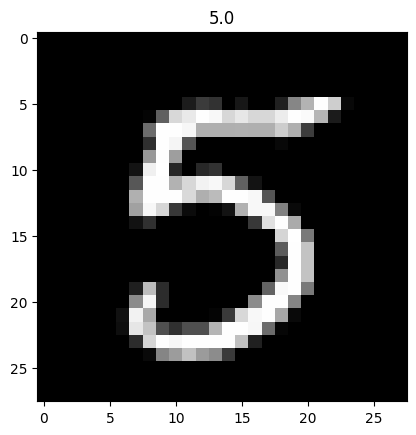

In [4]:
plt.imshow(data[1].reshape(28,28), cmap='gray');
plt.title(labels[1]);

In [5]:
# Tensors on GPU, split, loaders.
train_label = torch.tensor(labels, dtype=torch.long, device='cuda')
train_data = torch.tensor(data, dtype=torch.float, device='cuda')

train_data,test_data, train_labels,test_labels = train_test_split(train_data, train_label, test_size=.1)

trainDataSet = TensorDataset(train_data, train_labels)
testDataSet = TensorDataset(test_data, test_labels)

batchsize    = 32
train_loader = DataLoader(trainDataSet,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(testDataSet,batch_size=testDataSet.tensors[0].shape[0])

In [6]:
# A throwaway model for inspecting the freezing mechanics.
test_model = classifier()

In [7]:
# Freeze every parameter. requires_grad=False means autograd will not compute
# .grad for it, so optimizer.step() has nothing to apply.
for pname, yparams in test_model.named_parameters():
   yparams.requires_grad = False # Requires grad is boolean that turns on or off backpropogation for those certian parameters.

In [8]:
# Confirming every parameter now reports requires_grad=False.
for pname, yparams in test_model.named_parameters():
   print(f'{pname} : {yparams.requires_grad}')

input_layer.weight : False
input_layer.bias : False
fc1.weight : False
fc1.bias : False
fc2.weight : False
fc2.bias : False
output_layer.weight : False
output_layer.bias : False


In [9]:
# Printing a frozen Parameter no longer shows 'requires_grad=True' in its repr -
# a quick visual check that the flag took effect.
test_model.fc1.weight # When the requires_grad is set to False..we donot see it in the tensor...Only visible when it's set to true

Parameter containing:
tensor([[-0.0226, -0.0550, -0.0260,  ...,  0.1060,  0.0465,  0.0232],
        [-0.0832, -0.1075,  0.0307,  ..., -0.0029,  0.0482, -0.0587],
        [ 0.0551,  0.0128,  0.0703,  ..., -0.0193, -0.0967,  0.1001],
        ...,
        [ 0.0472, -0.1057, -0.0182,  ...,  0.0496,  0.0904, -0.0859],
        [-0.1165, -0.0116,  0.0803,  ..., -0.0235,  0.0187, -0.0496],
        [ 0.1128, -0.0511,  0.0100,  ..., -0.0012,  0.1005, -0.1071]])

In [10]:
# The two-phase schedule:
#   phase 1 (epochs 0-49): everything frozen except output_layer, lr=1e-6.
#     The frozen layers are a fixed random feature extractor and only the final
#     classifier learns.
#   phase 2 (epochs 50-99): unfreeze all, lr=1e-4.
#
# Note the optimizer is REBUILT after unfreezing - necessary, because an
# optimizer captures its parameter references at construction time.
# In real fine-tuning phase 2 usually uses a SMALLER learning rate than phase 1,
# to avoid destroying pretrained features; here the order is reversed because
# the frozen layers are random rather than pretrained.
def train_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    epochs = 100
    lossFunc = nn.CrossEntropyLoss()

    model = classifier().to(device)

    train_acc, test_acc, losses = [], [], []

    def freeze_all():
        for p in model.parameters():
            p.requires_grad = False

    def unfreeze_output_layer():
        for p in model.output_layer.parameters():
            p.requires_grad = True

    def unfreeze_all():
        for p in model.parameters():
            p.requires_grad = True

    freeze_all()
    unfreeze_output_layer()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-6)

    for epoch in range(epochs):

        if epoch == epochs // 2:
            unfreeze_all()
            optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

        model.train()
        batch_loss = []
        batch_acc = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            yhat = model(x)
            loss = lossFunc(yhat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_loss.append(loss.item())
            acc = (torch.argmax(yhat, dim=1) == y).float().mean().item() * 100
            batch_acc.append(acc)

        losses.append(float(np.mean(batch_loss)))
        train_acc.append(float(np.mean(batch_acc)))

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch} | Loss: {losses[-1]:.4f} | Train Acc: {train_acc[-1]:.2f}%")


        model.eval()
        with torch.no_grad():
            X, Y = next(iter(test_loader))
            pred = torch.argmax(model(X), dim=1)
            test_acc.append((pred == Y).float().mean().item() * 100)

    return train_acc, test_acc, losses

In [11]:
train_acc, test_acc, losses = train_model()

Epoch 0 | Loss: 8.8970 | Train Acc: 8.25%
Epoch 10 | Loss: 5.8057 | Train Acc: 7.91%
Epoch 20 | Loss: 4.9263 | Train Acc: 8.10%
Epoch 30 | Loss: 4.4642 | Train Acc: 8.57%
Epoch 40 | Loss: 4.1693 | Train Acc: 8.67%
Epoch 50 | Loss: 1.6613 | Train Acc: 47.15%
Epoch 60 | Loss: 0.3135 | Train Acc: 91.01%
Epoch 70 | Loss: 0.2233 | Train Acc: 93.52%
Epoch 80 | Loss: 0.1775 | Train Acc: 94.74%
Epoch 90 | Loss: 0.1471 | Train Acc: 95.77%
Epoch 99 | Loss: 0.1273 | Train Acc: 96.35%


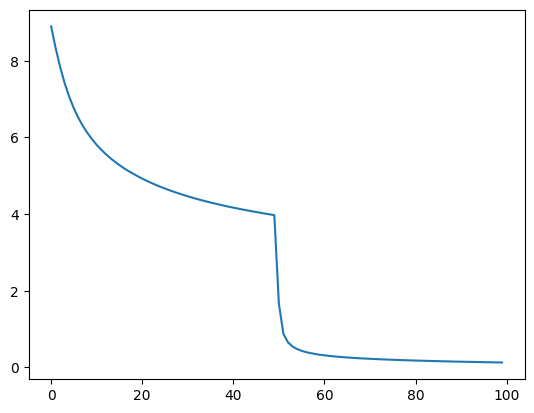

In [12]:
# Loss curve. Look for the discontinuity at epoch 50, where the unfreezing and
# the learning-rate change both take effect.
plt.plot(losses);

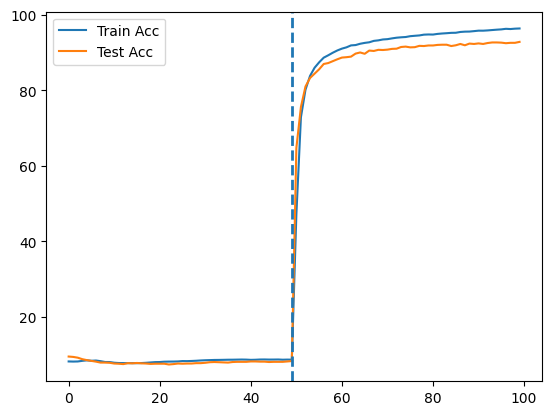

In [14]:
# Accuracy, with the dashed line marking the switch. The jump after it shows how
# much the frozen layers were holding the model back - a random feature
# extractor is a poor one. In transfer learning those frozen layers are
# pretrained instead, and phase 1 gets much further.
plt.plot(train_acc,label='Train Acc');
plt.plot(test_acc,label='Test Acc')
plt.axvline(x=49, linestyle='--', linewidth=2)
plt.legend();